# Comparison of Models - Flood

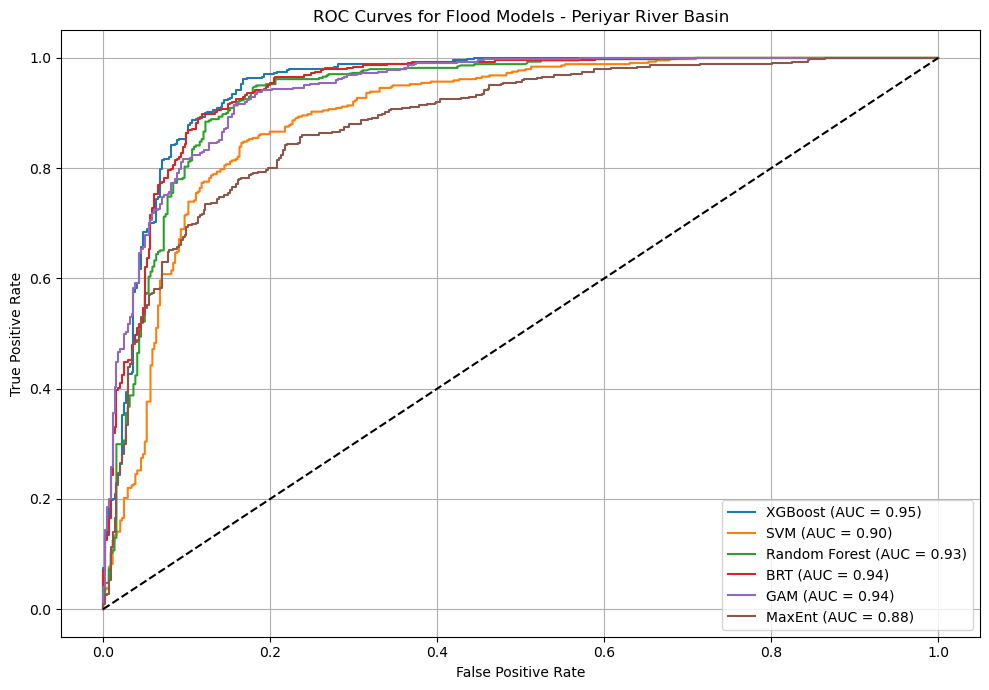

,Model,AUC,Accuracy,Precision,Recall,F1-score
0,XGBoost,0.947157,0.886621,0.860465,0.922902,0.890591
3,BRT,0.943732,0.883220,0.870614,0.900227,0.885173
4,GAM,0.940405,0.876417,0.848739,0.916100,0.881134
2,Random Forest,0.931741,0.878685,0.847917,0.922902,0.883822
1,SVM,0.895882,0.829932,0.792757,0.893424,0.840085
5,MaxEnt,0.884328,0.801587,0.794248,0.814059,0.804031


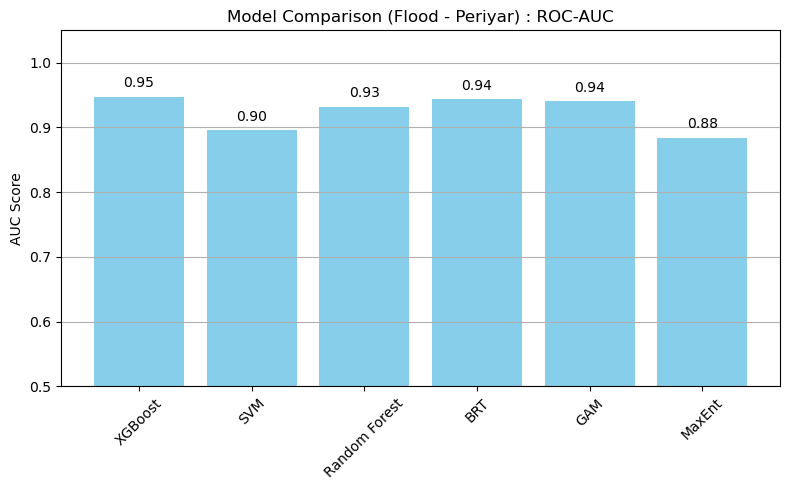

In [2]:
# 📦 1. Import Libraries
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, roc_curve, accuracy_score, precision_score, recall_score, f1_score

# 📁 2. Define Model Files and Names
results_path = r"C:\Users\megha\OneDrive - University of Twente\Thesis Data\ML Data\Results"
models = {
    "XGBoost": "XGBoost_Flood_Results.csv",
    "SVM": "SVM_Flood_Results.csv",
    "Random Forest": "RF_Flood_Results.csv",
    "BRT": "BRT_Flood_Results.csv",
    "GAM": "GAM_Flood_Results.csv",
    "MaxEnt": "MaxEnt_Flood_Results.csv"
}

# 📊 3. Initialize Metric Storage
metrics = []

# 📈 4. Plot ROC Curves
plt.figure(figsize=(10, 7))
for name, filename in models.items():
    df = pd.read_csv(f"{results_path}\\{filename}")
    y_true = df['True_Label']
    y_prob = df['Predicted_Prob']
    y_pred = df['Predicted_Label']
    
    # Compute ROC
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    auc = roc_auc_score(y_true, y_prob)

    # Store Metrics
    metrics.append({
        'Model': name,
        'AUC': auc,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall': recall_score(y_true, y_pred),
        'F1-score': f1_score(y_true, y_pred)
    })

    # Plot ROC
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.2f})")

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves for Flood Models - Periyar River Basin")
plt.legend()
plt.grid()
plt.tight_layout()
plt.savefig(r"C:\Users\megha\OneDrive - University of Twente\Thesis Data\ML Data\Results\ROC_Curves_Flood_Models.png", dpi=300)
plt.show()

# 📋 5. Show Metrics Table
df_metrics = pd.DataFrame(metrics)
display(df_metrics.sort_values(by="AUC", ascending=False))

# 📊 6. Bar Graph for AUC with Labels
plt.figure(figsize=(8, 5))
bars = plt.bar(df_metrics['Model'], df_metrics['AUC'], color='skyblue')

# Add text labels on bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 0.01, f"{yval:.2f}", ha='center', va='bottom', fontsize=10)
plt.savefig(r"C:\Users\megha\OneDrive - University of Twente\Thesis Data\ML Data\Results\AUC_Comparison_Barplot_Flood.png", dpi=300)

plt.ylabel("AUC Score")
plt.title("Model Comparison (Flood - Periyar) : ROC-AUC")
plt.ylim(0.5, 1.05)
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.tight_layout()

plt.show()



